# 09 - Cluster Analysis

This notebook analyzes the temporal clustering results from Phase 1.

**Clustering Horizons:**
- **Cumulative**: Performance from start (2020-01-01) to current week
- **Weekly**: Performance in current week only
- **Monthly**: Performance in current month

**Contents:**
1. Load clustering results
2. Cluster distribution analysis
3. Cluster stability over time
4. Cluster transitions
5. Method comparison
6. Algorithm behavior patterns

In [28]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths
PROCESSED_PATH = Path('../data/processed')
CLUSTER_PATH = PROCESSED_PATH / 'temporal_clusters'

print(f"Cluster results path: {CLUSTER_PATH}")
print(f"Files available: {list(CLUSTER_PATH.glob('*')) if CLUSTER_PATH.exists() else 'Directory not found'}")

Cluster results path: ..\data\processed\temporal_clusters
Files available: [WindowsPath('../data/processed/temporal_clusters/best_methods.json'), WindowsPath('../data/processed/temporal_clusters/CLUSTERING_REPORT.md'), WindowsPath('../data/processed/temporal_clusters/cluster_characteristics.csv'), WindowsPath('../data/processed/temporal_clusters/cluster_history.csv'), WindowsPath('../data/processed/temporal_clusters/cluster_history.parquet'), WindowsPath('../data/processed/temporal_clusters/method_comparison_cumulative.csv'), WindowsPath('../data/processed/temporal_clusters/method_comparison_monthly.csv'), WindowsPath('../data/processed/temporal_clusters/method_comparison_weekly.csv'), WindowsPath('../data/processed/temporal_clusters/params.json')]


## 1. Load Clustering Results

In [29]:
# Load cluster history
cluster_history = pd.read_parquet(CLUSTER_PATH / 'cluster_history.parquet')
cluster_history['week_end'] = pd.to_datetime(cluster_history['week_end'])

print(f"Cluster history shape: {cluster_history.shape}")
print(f"\nColumns: {cluster_history.columns.tolist()}")
print(f"\nDate range: {cluster_history['week_end'].min()} to {cluster_history['week_end'].max()}")
print(f"Number of weeks: {cluster_history['week_end'].nunique()}")
print(f"Number of algorithms: {cluster_history['algo_id'].nunique()}")

cluster_history.head(10)

Cluster history shape: (3243120, 5)

Columns: ['week_end', 'algo_id', 'cluster_cumulative', 'cluster_weekly', 'cluster_monthly']

Date range: 2020-06-05 00:00:00 to 2025-01-03 00:00:00
Number of weeks: 240
Number of algorithms: 13513


,week_end,algo_id,cluster_cumulative,cluster_weekly,cluster_monthly
0,2020-06-05,007XY,insufficient_data,insufficient_data,insufficient_data
1,2020-06-05,00eyz,insufficient_data,insufficient_data,insufficient_data
2,2020-06-05,00kZg,insufficient_data,insufficient_data,insufficient_data
3,2020-06-05,00lLe,insufficient_data,insufficient_data,insufficient_data
4,2020-06-05,00stS,insufficient_data,insufficient_data,insufficient_data
5,2020-06-05,00ufq,insufficient_data,insufficient_data,insufficient_data
6,2020-06-05,00wTX,insufficient_data,insufficient_data,insufficient_data
7,2020-06-05,00Zqs,insufficient_data,insufficient_data,insufficient_data
8,2020-06-05,01Jgc,insufficient_data,insufficient_data,insufficient_data
9,2020-06-05,01wS7,insufficient_data,insufficient_data,insufficient_data


In [30]:
# Load method comparison if available
method_comparisons = {}
for horizon in ['cumulative', 'weekly', 'monthly']:
    path = CLUSTER_PATH / f'method_comparison_{horizon}.csv'
    if path.exists():
        method_comparisons[horizon] = pd.read_csv(path, index_col='method')
        print(f"\n{horizon.upper()} method comparison:")
        display(method_comparisons[horizon])


CUMULATIVE method comparison:


,avg_silhouette,avg_calinski_harabasz,avg_davies_bouldin
method,,,
kmeans,0.607959,5624.510826,0.732856
gmm,0.466967,1692.815170,1.573894
hierarchical,0.578829,4997.426497,0.763060
dbscan,0.326049,638.896665,0.599987
autoencoder,0.468565,3861.458844,1.040942
vae,0.510154,3289.280007,1.126841
sparse_ae,0.521899,2839.788688,1.131742
iic,0.475445,2012.707062,1.294541
dac,NaN,NaN,NaN



WEEKLY method comparison:


,avg_silhouette,avg_calinski_harabasz,avg_davies_bouldin
method,,,
kmeans,0.716525,5952.335938,0.793159
gmm,0.658061,3507.564075,1.057440
hierarchical,0.688737,5195.129543,0.839204
dbscan,0.612795,2566.262937,0.605974
autoencoder,0.695799,5298.856557,0.922374
vae,0.683146,4069.734511,0.993454
sparse_ae,0.684983,4166.651580,0.964592
iic,0.649352,3365.316299,1.188917
dac,NaN,NaN,NaN



MONTHLY method comparison:


,avg_silhouette,avg_calinski_harabasz,avg_davies_bouldin
method,,,
kmeans,0.688965,6264.097830,0.812983
gmm,0.637056,3500.747360,1.130076
hierarchical,0.661202,5450.188624,0.806542
dbscan,0.449785,1472.170319,0.489730
autoencoder,0.674062,5437.690102,0.921966
vae,0.661280,4561.674646,0.978958
sparse_ae,0.642285,4734.012119,0.977303
iic,0.622351,3405.823345,1.182090
dac,NaN,NaN,NaN


In [31]:
# Load parameters
import json

with open(CLUSTER_PATH / 'params.json', 'r') as f:
    params = json.load(f)

print("Clustering Parameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

Clustering Parameters:
  start_date: 2020-01-01
  n_clusters: 5
  method: kmeans
  n_weeks: 240
  n_algos: 13513


## 2. Cluster Distribution Analysis

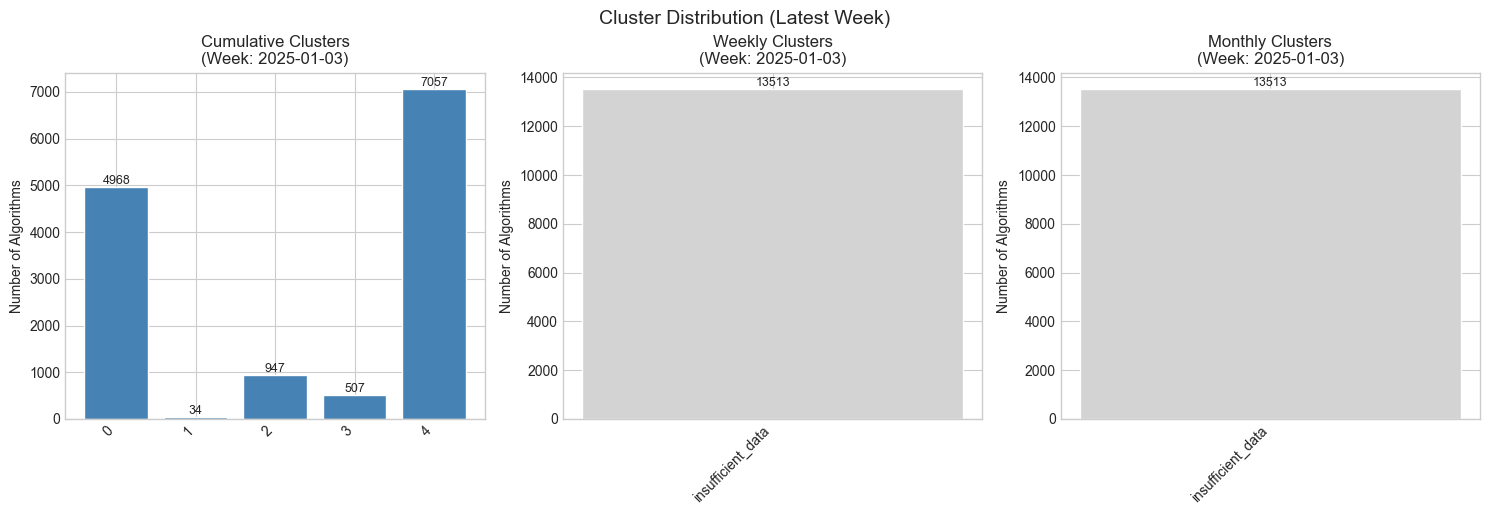

In [32]:
# Get last week's cluster distribution
last_week = cluster_history['week_end'].max()
last_week_data = cluster_history[cluster_history['week_end'] == last_week]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, horizon in zip(axes, ['cluster_cumulative', 'cluster_weekly', 'cluster_monthly']):
    counts = last_week_data[horizon].value_counts()
    
    # Separate numeric clusters from special labels
    numeric = counts[counts.index.str.match(r'^\d+$', na=False)].sort_index()
    special = counts[~counts.index.str.match(r'^\d+$', na=False)]
    
    # Plot
    all_counts = pd.concat([numeric, special])
    colors = ['steelblue'] * len(numeric) + ['lightgray'] * len(special)
    
    bars = ax.bar(range(len(all_counts)), all_counts.values, color=colors)
    ax.set_xticks(range(len(all_counts)))
    ax.set_xticklabels(all_counts.index, rotation=45, ha='right')
    ax.set_title(f"{horizon.replace('cluster_', '').title()} Clusters\n(Week: {last_week.date()})")
    ax.set_ylabel('Number of Algorithms')
    
    # Add value labels
    for bar, val in zip(bars, all_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Cluster Distribution (Latest Week)', y=1.02, fontsize=14)
plt.show()

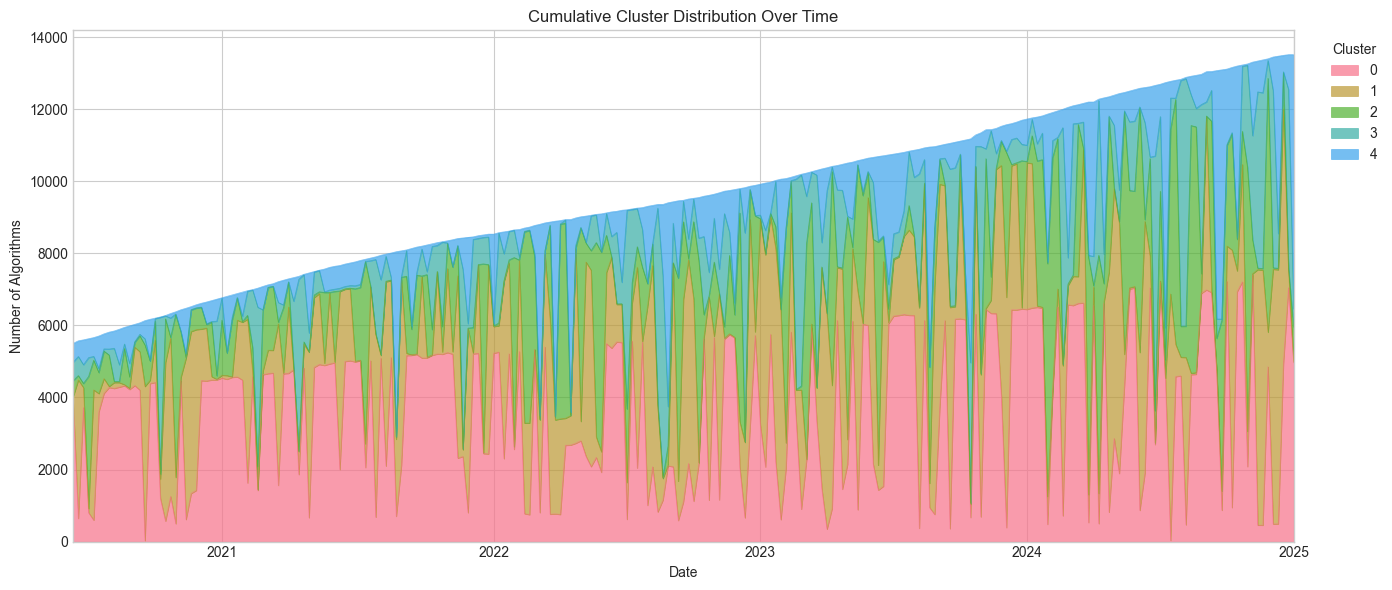

In [33]:
# Cluster distribution over time (for cumulative clusters)
def plot_cluster_evolution(df, cluster_col, title):
    # Filter out inactive/insufficient
    active = df[~df[cluster_col].isin(['inactive', 'insufficient_data', 'error'])].copy()
    
    # Count by week
    weekly_counts = active.groupby(['week_end', cluster_col]).size().unstack(fill_value=0)
    
    # Plot stacked area
    fig, ax = plt.subplots(figsize=(14, 6))
    weekly_counts.plot.area(ax=ax, alpha=0.7, linewidth=0.5)
    
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Algorithms')
    ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    return weekly_counts

cumulative_evolution = plot_cluster_evolution(
    cluster_history, 'cluster_cumulative', 
    'Cumulative Cluster Distribution Over Time'
)

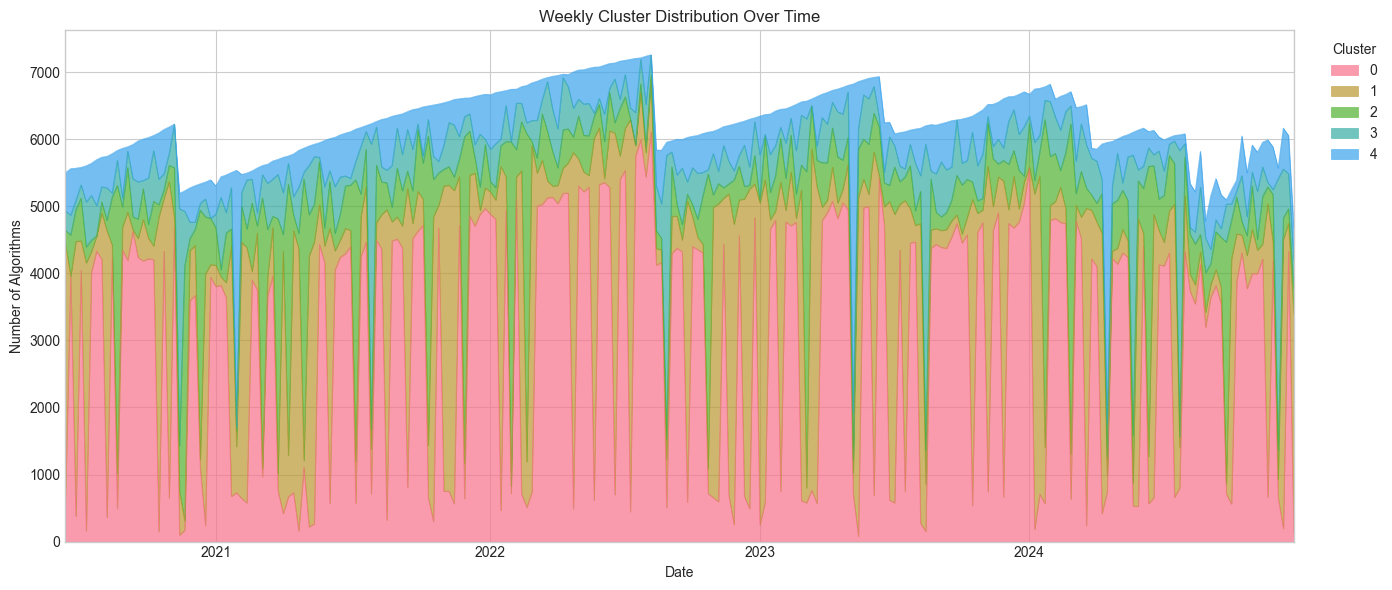

In [34]:
# Weekly cluster evolution (more volatile)
weekly_evolution = plot_cluster_evolution(
    cluster_history, 'cluster_weekly',
    'Weekly Cluster Distribution Over Time'
)

## 3. Cluster Stability Analysis

In [35]:
def compute_stability(df, cluster_col):
    """Compute cluster stability per algorithm."""
    stability_data = []
    
    for algo_id, group in df.groupby('algo_id'):
        # Filter active clusters only
        active = group[~group[cluster_col].isin(['inactive', 'insufficient_data', 'error'])]
        
        if len(active) < 2:
            stability_data.append({
                'algo_id': algo_id,
                'n_weeks': len(active),
                'n_changes': 0,
                'stability': 1.0,
                'dominant_cluster': active[cluster_col].mode().iloc[0] if len(active) > 0 else None,
                'n_unique_clusters': active[cluster_col].nunique()
            })
            continue
        
        clusters = active.sort_values('week_end')[cluster_col]
        n_changes = (clusters != clusters.shift()).sum() - 1
        stability = 1 - (n_changes / (len(clusters) - 1))
        
        stability_data.append({
            'algo_id': algo_id,
            'n_weeks': len(active),
            'n_changes': n_changes,
            'stability': stability,
            'dominant_cluster': clusters.mode().iloc[0],
            'n_unique_clusters': clusters.nunique()
        })
    
    return pd.DataFrame(stability_data)

# Compute stability for each horizon
stability_cumulative = compute_stability(cluster_history, 'cluster_cumulative')
stability_weekly = compute_stability(cluster_history, 'cluster_weekly')
stability_monthly = compute_stability(cluster_history, 'cluster_monthly')

print("STABILITY SUMMARY")
print("="*50)
for name, stab in [('Cumulative', stability_cumulative), 
                    ('Weekly', stability_weekly), 
                    ('Monthly', stability_monthly)]:
    print(f"\n{name}:")
    print(f"  Mean stability: {stab['stability'].mean():.3f}")
    print(f"  Median stability: {stab['stability'].median():.3f}")
    print(f"  Mean cluster changes: {stab['n_changes'].mean():.1f}")
    print(f"  Mean unique clusters visited: {stab['n_unique_clusters'].mean():.1f}")

STABILITY SUMMARY

Cumulative:
  Mean stability: 0.297
  Median stability: 0.297
  Mean cluster changes: 115.7
  Mean unique clusters visited: 5.0

Weekly:
  Mean stability: 0.349
  Median stability: 0.381
  Mean cluster changes: 69.3
  Mean unique clusters visited: 4.7

Monthly:
  Mean stability: 0.376
  Median stability: 0.415
  Mean cluster changes: 58.3
  Mean unique clusters visited: 4.6


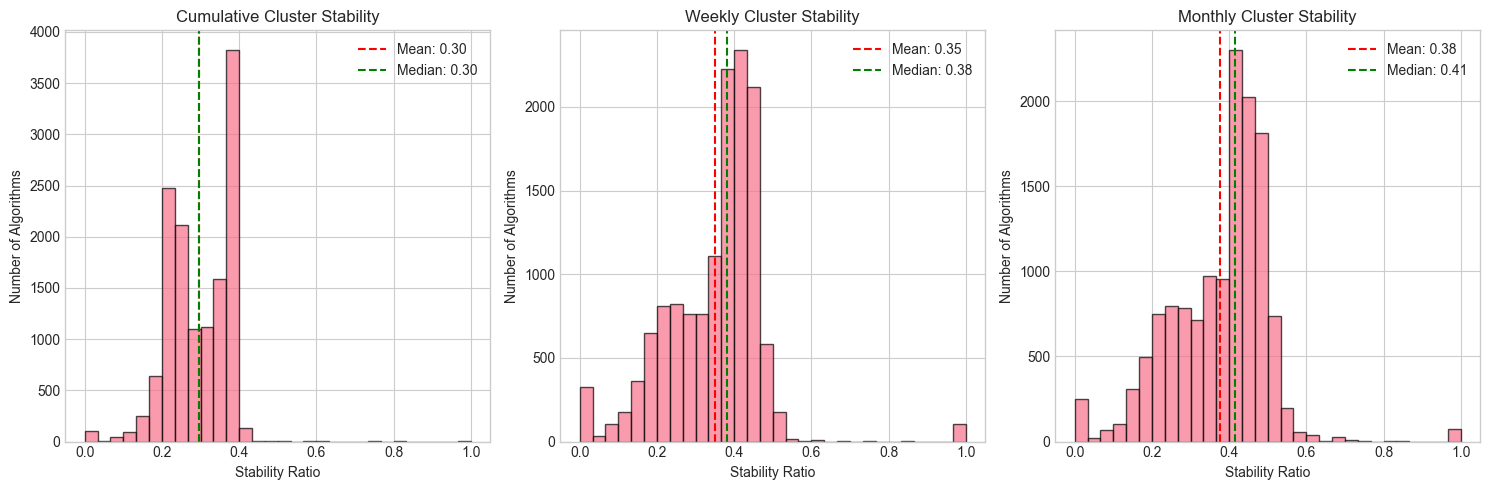

In [36]:
# Stability distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, stab) in zip(axes, [('Cumulative', stability_cumulative), 
                                     ('Weekly', stability_weekly), 
                                     ('Monthly', stability_monthly)]):
    ax.hist(stab['stability'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(stab['stability'].mean(), color='red', linestyle='--', 
               label=f"Mean: {stab['stability'].mean():.2f}")
    ax.axvline(stab['stability'].median(), color='green', linestyle='--',
               label=f"Median: {stab['stability'].median():.2f}")
    ax.set_title(f'{name} Cluster Stability')
    ax.set_xlabel('Stability Ratio')
    ax.set_ylabel('Number of Algorithms')
    ax.legend()

plt.tight_layout()
plt.show()

In [37]:
# Most and least stable algorithms
print("MOST STABLE ALGORITHMS (Cumulative)")
print("="*60)
display(stability_cumulative.nlargest(10, 'stability')[['algo_id', 'stability', 'n_changes', 'dominant_cluster', 'n_weeks']])

print("\nLEAST STABLE ALGORITHMS (Cumulative)")
print("="*60)
display(stability_cumulative.nsmallest(10, 'stability')[['algo_id', 'stability', 'n_changes', 'dominant_cluster', 'n_weeks']])

MOST STABLE ALGORITHMS (Cumulative)


,algo_id,stability,n_changes,dominant_cluster,n_weeks
11484,qeq32,1.000000,0,0,2
11587,rAOKC,1.000000,0,3,2
11792,sD2Va,1.000000,0,3,2
6847,VRnGr,0.800000,1,1,6
514,2IKvT,0.750000,1,0,5
1166,5JN5a,0.750000,1,1,5
3045,DbHwr,0.750000,1,0,5
13171,yWj1Q,0.600000,2,1,6
4959,MWMpr,0.571429,3,1,8
363,1gyHQ,0.500000,2,1,5



LEAST STABLE ALGORITHMS (Cumulative)


,algo_id,stability,n_changes,dominant_cluster,n_weeks
100,0Sf8q,0.0,1,1,2
457,24Nbo,0.0,4,2,5
462,25EPw,0.0,3,2,4
784,3ZLzY,0.0,6,0,7
800,3dwIA,0.0,12,1,13
859,3wl0B,0.0,1,1,2
860,3xO08,0.0,2,1,3
983,4SxDr,0.0,1,1,2
1348,67FGl,0.0,2,1,3
1349,67LTd,0.0,4,1,5


## 4. Cluster Transitions

In [38]:
def compute_transitions(df, cluster_col):
    """Compute transition matrix between clusters."""
    # Filter out special labels
    active = df[~df[cluster_col].isin(['inactive', 'insufficient_data', 'error'])].copy()
    active = active.sort_values(['algo_id', 'week_end'])
    
    # Add previous cluster
    active['prev_cluster'] = active.groupby('algo_id')[cluster_col].shift(1)
    
    # Filter to actual transitions (not first week)
    transitions = active[active['prev_cluster'].notna()]
    
    # Count transitions
    transition_counts = transitions.groupby(['prev_cluster', cluster_col]).size().unstack(fill_value=0)
    
    # Normalize to probabilities
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    
    return transition_counts, transition_probs

trans_counts, trans_probs = compute_transitions(cluster_history, 'cluster_cumulative')

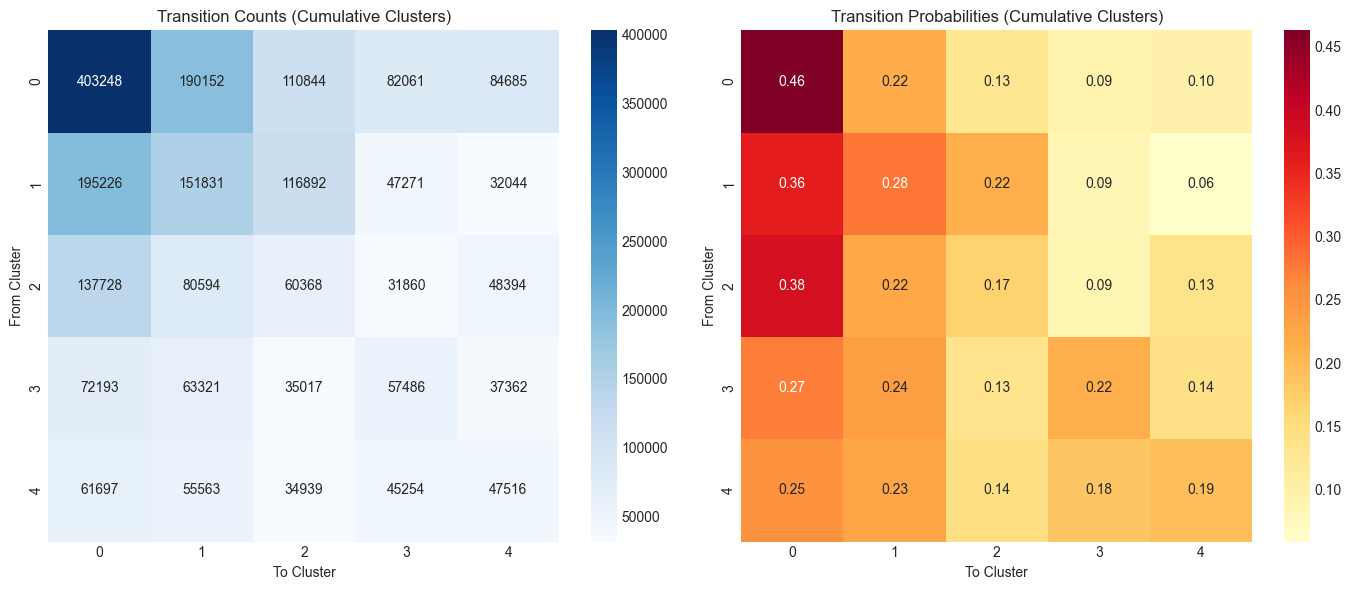

In [39]:
# Plot transition matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Counts
sns.heatmap(trans_counts, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Transition Counts (Cumulative Clusters)')
axes[0].set_xlabel('To Cluster')
axes[0].set_ylabel('From Cluster')

# Probabilities
sns.heatmap(trans_probs, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Transition Probabilities (Cumulative Clusters)')
axes[1].set_xlabel('To Cluster')
axes[1].set_ylabel('From Cluster')

plt.tight_layout()
plt.show()

In [40]:
# Top transitions (excluding self-transitions)
trans_flat = trans_counts.stack().reset_index()
trans_flat.columns = ['from_cluster', 'to_cluster', 'count']
trans_flat = trans_flat[trans_flat['from_cluster'] != trans_flat['to_cluster']]
trans_flat = trans_flat.sort_values('count', ascending=False)

print("TOP 15 CLUSTER TRANSITIONS (excluding self)")
print("="*50)
display(trans_flat.head(15))

TOP 15 CLUSTER TRANSITIONS (excluding self)


,from_cluster,to_cluster,count
5,1,0,195226
1,0,1,190152
10,2,0,137728
7,1,2,116892
2,0,2,110844
4,0,4,84685
3,0,3,82061
11,2,1,80594
15,3,0,72193
16,3,1,63321


## 5. Method Comparison

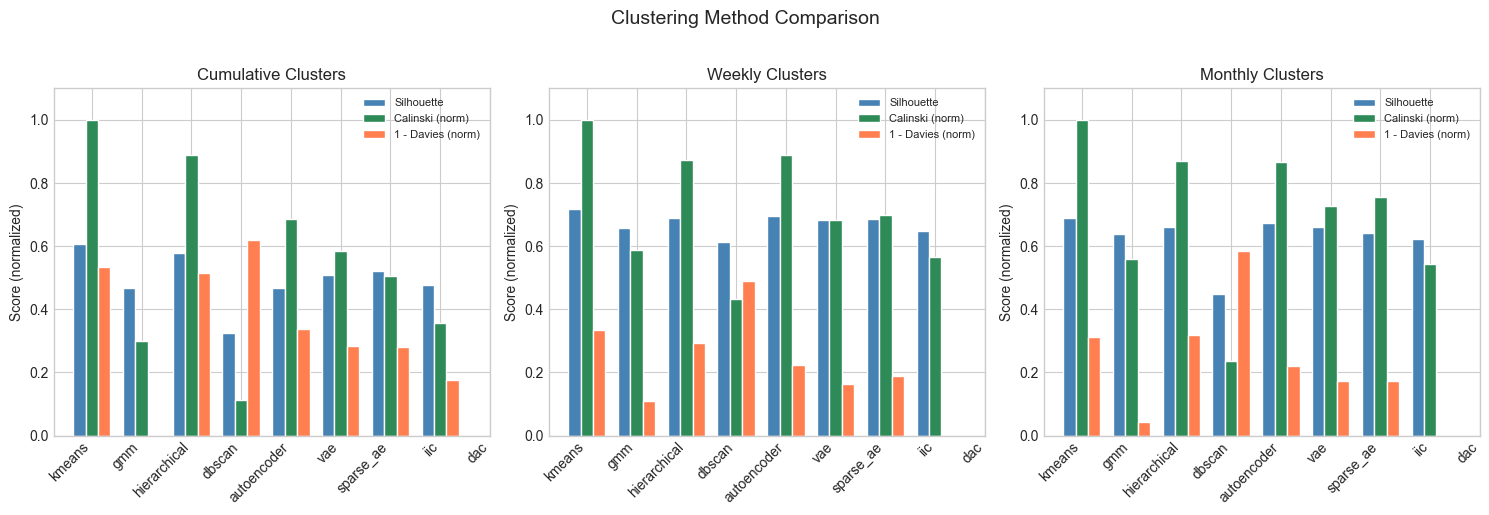

In [41]:
if method_comparisons:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, (horizon, df) in zip(axes, method_comparisons.items()):
        x = range(len(df))
        width = 0.25
        
        ax.bar([i - width for i in x], df['avg_silhouette'], width, label='Silhouette', color='steelblue')
        ax.bar([i for i in x], df['avg_calinski_harabasz'] / df['avg_calinski_harabasz'].max(), 
               width, label='Calinski (norm)', color='seagreen')
        ax.bar([i + width for i in x], 1 - df['avg_davies_bouldin'] / df['avg_davies_bouldin'].max(), 
               width, label='1 - Davies (norm)', color='coral')
        
        ax.set_xticks(x)
        ax.set_xticklabels(df.index, rotation=45, ha='right')
        ax.set_title(f'{horizon.title()} Clusters')
        ax.set_ylabel('Score (normalized)')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_ylim(0, 1.1)
    
    plt.suptitle('Clustering Method Comparison', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No method comparison data available. Run with --compare-methods flag.")

In [42]:
# Best method per horizon
if method_comparisons:
    print("BEST METHODS BY SILHOUETTE SCORE")
    print("="*50)
    for horizon, df in method_comparisons.items():
        best = df['avg_silhouette'].idxmax()
        score = df.loc[best, 'avg_silhouette']
        print(f"  {horizon.title()}: {best} (silhouette = {score:.4f})")

BEST METHODS BY SILHOUETTE SCORE
  Cumulative: kmeans (silhouette = 0.6080)
  Weekly: kmeans (silhouette = 0.7165)
  Monthly: kmeans (silhouette = 0.6890)


## 6. Algorithm Behavior Patterns

Last week: 2025-01-03
Total algorithms: 13513
Active (both horizons): 0

No active algorithms in both horizons for the last week.
This may happen if clustering was run on a sample or if data is sparse.

Week with most active cluster_cumulative: 2024-12-27 (13513 algos)

Week with most active cluster_weekly: 2022-08-12 (7258 algos)

--- Showing cross-tab for week with most cumulative data ---


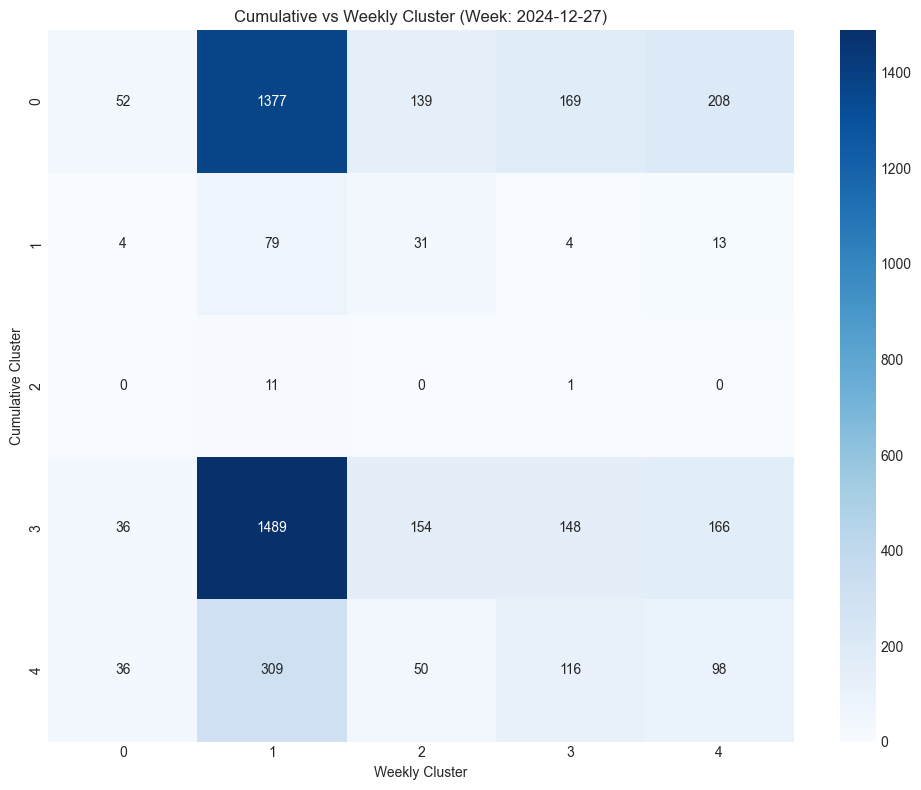

In [43]:
# Cross-tabulation: cumulative vs weekly clusters (last week)
last_week_data = cluster_history[cluster_history['week_end'] == cluster_history['week_end'].max()]

# Filter active only
active_last = last_week_data[
    ~last_week_data['cluster_cumulative'].isin(['inactive', 'insufficient_data', 'error']) &
    ~last_week_data['cluster_weekly'].isin(['inactive', 'insufficient_data', 'error'])
]

print(f"Last week: {cluster_history['week_end'].max().date()}")
print(f"Total algorithms: {len(last_week_data)}")
print(f"Active (both horizons): {len(active_last)}")

if len(active_last) > 0:
    cross_tab = pd.crosstab(active_last['cluster_cumulative'], active_last['cluster_weekly'])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Cumulative vs Weekly Cluster (Week: {last_week.date()})')
    ax.set_xlabel('Weekly Cluster')
    ax.set_ylabel('Cumulative Cluster')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo active algorithms in both horizons for the last week.")
    print("This may happen if clustering was run on a sample or if data is sparse.")
    
    # Try finding a week with active data
    for cluster_col in ['cluster_cumulative', 'cluster_weekly']:
        active_counts = cluster_history.groupby('week_end')[cluster_col].apply(
            lambda x: (~x.isin(['inactive', 'insufficient_data', 'error'])).sum()
        )
        best_week = active_counts.idxmax()
        print(f"\nWeek with most active {cluster_col}: {best_week.date()} ({active_counts[best_week]} algos)")
    
    # Show cross-tab for a week with more data
    print("\n--- Showing cross-tab for week with most cumulative data ---")
    best_week_cumulative = cluster_history.groupby('week_end')['cluster_cumulative'].apply(
        lambda x: (~x.isin(['inactive', 'insufficient_data', 'error'])).sum()
    ).idxmax()
    
    best_week_data = cluster_history[cluster_history['week_end'] == best_week_cumulative]
    active_best = best_week_data[
        ~best_week_data['cluster_cumulative'].isin(['inactive', 'insufficient_data', 'error']) &
        ~best_week_data['cluster_weekly'].isin(['inactive', 'insufficient_data', 'error'])
    ]
    
    if len(active_best) > 0:
        cross_tab = pd.crosstab(active_best['cluster_cumulative'], active_best['cluster_weekly'])
        
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'Cumulative vs Weekly Cluster (Week: {best_week_cumulative.date()})')
        ax.set_xlabel('Weekly Cluster')
        ax.set_ylabel('Cumulative Cluster')
        plt.tight_layout()
        plt.show()

In [44]:
# Consistency between horizons
def measure_consistency(row):
    """Check if all three horizons agree."""
    vals = [row['cluster_cumulative'], row['cluster_weekly'], row['cluster_monthly']]
    # Filter out inactive
    active_vals = [v for v in vals if v not in ['inactive', 'insufficient_data', 'error']]
    if len(active_vals) < 2:
        return None
    return len(set(active_vals)) == 1

last_week_data = last_week_data.copy()
last_week_data['all_same'] = last_week_data.apply(measure_consistency, axis=1)

consistency = last_week_data['all_same'].value_counts(dropna=True)
print(f"\nCLUSTER CONSISTENCY (Latest Week)")
print("="*50)
print(f"All horizons agree: {consistency.get(True, 0)} algorithms")
print(f"Horizons differ: {consistency.get(False, 0)} algorithms")
if len(consistency) > 0:
    total = consistency.sum()
    print(f"Consistency rate: {consistency.get(True, 0) / total * 100:.1f}%")


CLUSTER CONSISTENCY (Latest Week)
All horizons agree: 0 algorithms
Horizons differ: 0 algorithms


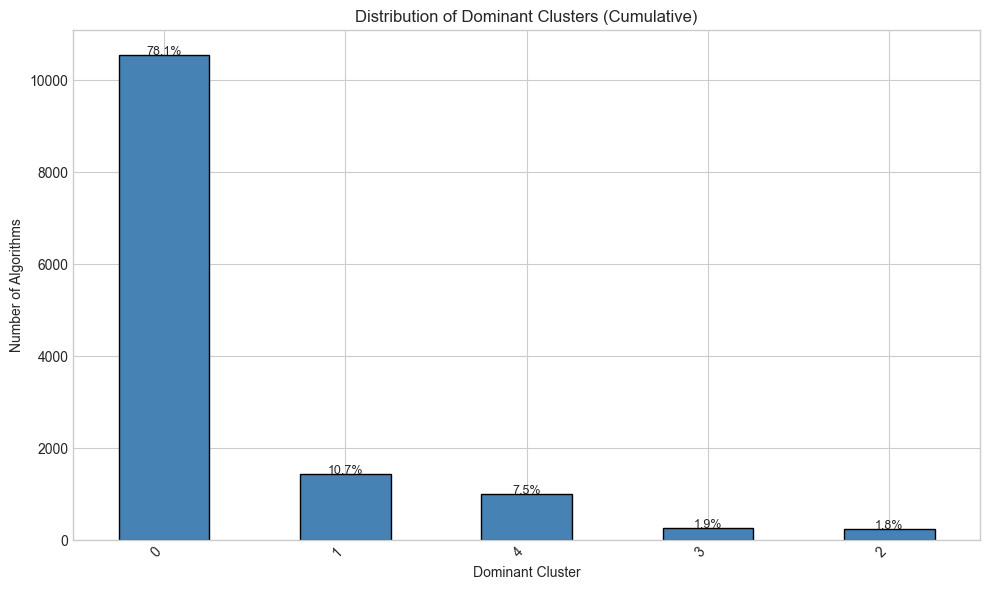

In [45]:
# Algorithms by dominant cluster (cumulative)
dominant_dist = stability_cumulative['dominant_cluster'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
dominant_dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribution of Dominant Clusters (Cumulative)')
ax.set_xlabel('Dominant Cluster')
ax.set_ylabel('Number of Algorithms')
plt.xticks(rotation=45, ha='right')

# Add percentage labels
total = len(stability_cumulative)
for i, v in enumerate(dominant_dist.values):
    ax.text(i, v + 0.5, f'{v/total*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

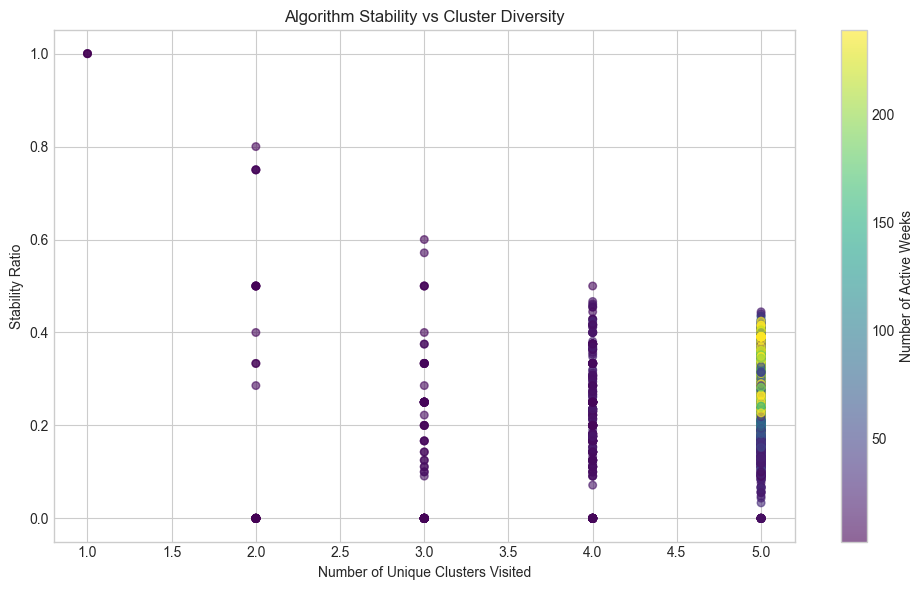

In [46]:
# Stability vs number of unique clusters
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    stability_cumulative['n_unique_clusters'],
    stability_cumulative['stability'],
    c=stability_cumulative['n_weeks'],
    cmap='viridis',
    alpha=0.6,
    s=30
)

ax.set_xlabel('Number of Unique Clusters Visited')
ax.set_ylabel('Stability Ratio')
ax.set_title('Algorithm Stability vs Cluster Diversity')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Number of Active Weeks')

plt.tight_layout()
plt.show()

## 7. Cluster Characteristics Analysis

Extract and analyze the performance characteristics of each cluster (high return, high volatility, etc.)

In [47]:
# Load algorithm features computed in Phase 1
algo_features_path = PROCESSED_PATH / 'algo_features.parquet'

if algo_features_path.exists():
    print("Loading algo_features.parquet...")
    algo_features = pd.read_parquet(algo_features_path)
    print(f"  Shape: {algo_features.shape}")
    print(f"  Date range: {algo_features.index.min()} to {algo_features.index.max()}")
    
    # Extract algo IDs from column names (format: {algo_id}_{feature})
    feature_types = ['return', 'volatility', 'drawdown', 'sharpe', 'profit_factor', 
                     'calmar_ratio', 'max_drawdown']
    
    # Get unique algo IDs
    algo_ids_from_features = set()
    for col in algo_features.columns:
        if '_' in col and not col.startswith('rolling_market'):
            algo_id = col.rsplit('_', 1)[0]
            # Handle multi-part algo IDs (e.g., 2DswP_rolling_return_5d -> 2DswP)
            for feat in feature_types + ['rolling_return', 'rolling_volatility', 'rolling_drawdown', 
                                          'rolling_sharpe', 'rolling_profit_factor', 'rolling_calmar']:
                if f'_{feat}' in col:
                    algo_id = col.split(f'_{feat}')[0]
                    break
            algo_ids_from_features.add(algo_id)
    
    print(f"  Algorithms in features: {len(algo_ids_from_features)}")
else:
    print("algo_features.parquet not found. Will compute from clustering features.")

Loading algo_features.parquet...
  Shape: (1430, 337831)
  Date range: 2020-06-02 00:00:00 to 2024-12-30 00:00:00
  Algorithms in features: 40539


In [48]:
# Extract latest features per algorithm
def extract_algo_features(algo_features_df, feature_types=['return', 'volatility', 'sharpe', 'max_drawdown']):
    """Extract the latest valid feature value for each algorithm."""
    algo_data = {}
    
    for col in algo_features_df.columns:
        if col.startswith('rolling_market'):
            continue
            
        # Parse column name to get algo_id and feature
        for feat in feature_types:
            if col.endswith(f'_{feat}'):
                algo_id = col[:-len(f'_{feat}')]
                
                # Get last valid value
                series = algo_features_df[col].dropna()
                if len(series) > 0:
                    if algo_id not in algo_data:
                        algo_data[algo_id] = {}
                    algo_data[algo_id][feat] = series.iloc[-1]
                break
    
    return pd.DataFrame(algo_data).T

if algo_features_path.exists():
    # Extract cumulative features (return, volatility, sharpe, max_drawdown)
    algo_summary = extract_algo_features(algo_features, 
                                          ['return', 'volatility', 'sharpe', 'max_drawdown', 
                                           'drawdown', 'calmar_ratio', 'profit_factor'])
    algo_summary.index.name = 'algo_id'
    print(f"Extracted features for {len(algo_summary)} algorithms")
    print(f"\nFeature summary:")
    display(algo_summary.describe().round(4))

Extracted features for 13513 algorithms

Feature summary:


,return,volatility,drawdown,sharpe,profit_factor,calmar_ratio,max_drawdown
count,13513.0000,13513.0000,13513.0000,13513.0000,10219.0000,13513.0000,13513.0000
mean,-0.0422,0.0349,-0.0847,-0.1820,0.8937,-0.0247,-0.1034
std,0.1152,0.0319,0.0997,0.3960,0.9485,0.2404,0.1053
min,-0.7972,0.0000,-0.7976,-2.5160,0.0000,-0.3068,-0.7990
25%,-0.0877,0.0028,-0.1294,-0.4389,0.6732,-0.1412,-0.1591
50%,-0.0126,0.0299,-0.0530,-0.0656,0.8680,-0.0359,-0.0805
75%,0.0000,0.0555,0.0000,0.0000,1.0243,0.0000,-0.0040
max,1.0824,0.4971,0.0000,2.2058,66.5645,11.4110,0.0000


In [49]:
# Merge features with cluster assignments
if algo_features_path.exists() and len(algo_summary) > 0:
    # Get dominant cluster from stability analysis (most frequent cluster for each algo)
    cluster_merged = stability_cumulative[['algo_id', 'dominant_cluster', 'stability']].merge(
        algo_summary.reset_index(), on='algo_id', how='inner'
    )
    print(f"Merged: {len(cluster_merged)} algorithms with both clusters and features")
    
    # Exclude special clusters
    cluster_merged_active = cluster_merged[
        ~cluster_merged['dominant_cluster'].isin(['inactive', 'insufficient_data', 'error', None])
    ]
    print(f"Active clusters: {len(cluster_merged_active)} algorithms")
    
    if len(cluster_merged_active) > 0:
        # Compute cluster characteristics
        feature_cols = [c for c in algo_summary.columns if c in cluster_merged_active.columns]
        
        cluster_chars = cluster_merged_active.groupby('dominant_cluster')[feature_cols + ['stability']].agg(['mean', 'std', 'count'])
        
        # Flatten column names
        cluster_chars.columns = ['_'.join(col).strip() for col in cluster_chars.columns.values]
        
        print("\n" + "="*80)
        print("CLUSTER CHARACTERISTICS (by dominant cluster)")
        print("="*80)
        display(cluster_chars.round(4))
else:
    print("Cannot compute cluster characteristics - missing features or cluster data")

Merged: 13513 algorithms with both clusters and features
Active clusters: 13513 algorithms

CLUSTER CHARACTERISTICS (by dominant cluster)


,return_mean,return_std,return_count,volatility_mean,volatility_std,volatility_count,drawdown_mean,drawdown_std,drawdown_count,sharpe_mean,...,profit_factor_count,calmar_ratio_mean,calmar_ratio_std,calmar_ratio_count,max_drawdown_mean,max_drawdown_std,max_drawdown_count,stability_mean,stability_std,stability_count
dominant_cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.0450,0.1039,10559,0.0349,0.0335,10559,-0.0832,0.1013,10559,-0.1647,...,7275,-0.0416,0.1015,10559,-0.1022,0.1082,10559,0.3182,0.0731,10559
1,-0.0882,0.1131,1441,0.0345,0.0245,1441,-0.1113,0.1063,1441,-0.4755,...,1432,-0.0891,0.4576,1441,-0.1248,0.1082,1441,0.2344,0.0573,1441
2,0.0165,0.1073,237,0.0305,0.0203,237,-0.0518,0.0782,237,0.2742,...,237,0.4231,0.8305,237,-0.0735,0.0808,237,0.1982,0.0972,237
3,-0.0738,0.0976,262,0.0331,0.0199,262,-0.1020,0.0801,262,-0.4019,...,262,-0.0695,0.2484,262,-0.1165,0.0820,262,0.2148,0.0914,262
4,0.0466,0.1707,1014,0.0371,0.0281,1014,-0.0653,0.0695,1014,0.0048,...,1013,0.1496,0.3202,1014,-0.0889,0.0696,1014,0.2138,0.0449,1014


In [50]:
# Generate descriptive labels for each cluster
def describe_cluster(row, all_data):
    """Generate a descriptive label for a cluster based on its characteristics."""
    labels = []
    
    # Get median values across all clusters for comparison
    medians = all_data.median()
    
    # Return
    if 'return' in row.index:
        ret = row['return']
        if ret > medians['return'] * 1.5:
            labels.append('High Return')
        elif ret < medians['return'] * 0.5 or ret < 0:
            labels.append('Low/Negative Return')
    
    # Volatility
    if 'volatility' in row.index:
        vol = row['volatility']
        if vol > medians['volatility'] * 1.5:
            labels.append('High Volatility')
        elif vol < medians['volatility'] * 0.5:
            labels.append('Low Volatility')
    
    # Sharpe
    if 'sharpe' in row.index:
        sharpe = row['sharpe']
        if sharpe > 1.0:
            labels.append('Excellent Sharpe (>1)')
        elif sharpe > 0.5:
            labels.append('Good Sharpe')
        elif sharpe < 0:
            labels.append('Negative Sharpe')
    
    # Drawdown
    if 'max_drawdown' in row.index:
        dd = abs(row['max_drawdown'])
        if dd > 0.3:
            labels.append('High Drawdown (>30%)')
        elif dd < 0.1:
            labels.append('Low Drawdown (<10%)')
    
    # Profit factor
    if 'profit_factor' in row.index:
        pf = row['profit_factor']
        if pf > 2.0:
            labels.append('High Profit Factor')
        elif pf < 1.0:
            labels.append('Losing (PF<1)')
    
    return ' | '.join(labels) if labels else 'Average Performance'

if algo_features_path.exists() and 'cluster_merged_active' in dir() and len(cluster_merged_active) > 0:
    # Compute mean features per cluster
    cluster_means = cluster_merged_active.groupby('dominant_cluster')[feature_cols].mean()
    
    # Generate descriptions
    cluster_descriptions = cluster_means.apply(lambda row: describe_cluster(row, cluster_means), axis=1)
    
    print("\n" + "="*80)
    print("CLUSTER DESCRIPTIONS (Interpretive Labels)")
    print("="*80)
    
    for cluster_id in sorted(cluster_means.index):
        desc = cluster_descriptions[cluster_id]
        n_algos = (cluster_merged_active['dominant_cluster'] == cluster_id).sum()
        print(f"\n📊 Cluster {cluster_id} ({n_algos} algorithms)")
        print(f"   {desc}")
        print(f"   └─ Return: {cluster_means.loc[cluster_id, 'return']:.2%}" if 'return' in cluster_means.columns else "")
        print(f"   └─ Volatility: {cluster_means.loc[cluster_id, 'volatility']:.2%}" if 'volatility' in cluster_means.columns else "")
        print(f"   └─ Sharpe: {cluster_means.loc[cluster_id, 'sharpe']:.3f}" if 'sharpe' in cluster_means.columns else "")
        print(f"   └─ Max Drawdown: {cluster_means.loc[cluster_id, 'max_drawdown']:.2%}" if 'max_drawdown' in cluster_means.columns else "")


CLUSTER DESCRIPTIONS (Interpretive Labels)

📊 Cluster 0 (10559 algorithms)
   High Return | Negative Sharpe | Losing (PF<1)
   └─ Return: -4.50%
   └─ Volatility: 3.49%
   └─ Sharpe: -0.165
   └─ Max Drawdown: -10.22%

📊 Cluster 1 (1441 algorithms)
   Low/Negative Return | Negative Sharpe | Losing (PF<1)
   └─ Return: -8.82%
   └─ Volatility: 3.45%
   └─ Sharpe: -0.476
   └─ Max Drawdown: -12.48%

📊 Cluster 2 (237 algorithms)
   High Return | Low Drawdown (<10%) | High Profit Factor
   └─ Return: 1.65%
   └─ Volatility: 3.05%
   └─ Sharpe: 0.274
   └─ Max Drawdown: -7.35%

📊 Cluster 3 (262 algorithms)
   Low/Negative Return | Negative Sharpe | Losing (PF<1)
   └─ Return: -7.38%
   └─ Volatility: 3.31%
   └─ Sharpe: -0.402
   └─ Max Drawdown: -11.65%

📊 Cluster 4 (1014 algorithms)
   High Return | Low Drawdown (<10%)
   └─ Return: 4.66%
   └─ Volatility: 3.71%
   └─ Sharpe: 0.005
   └─ Max Drawdown: -8.89%


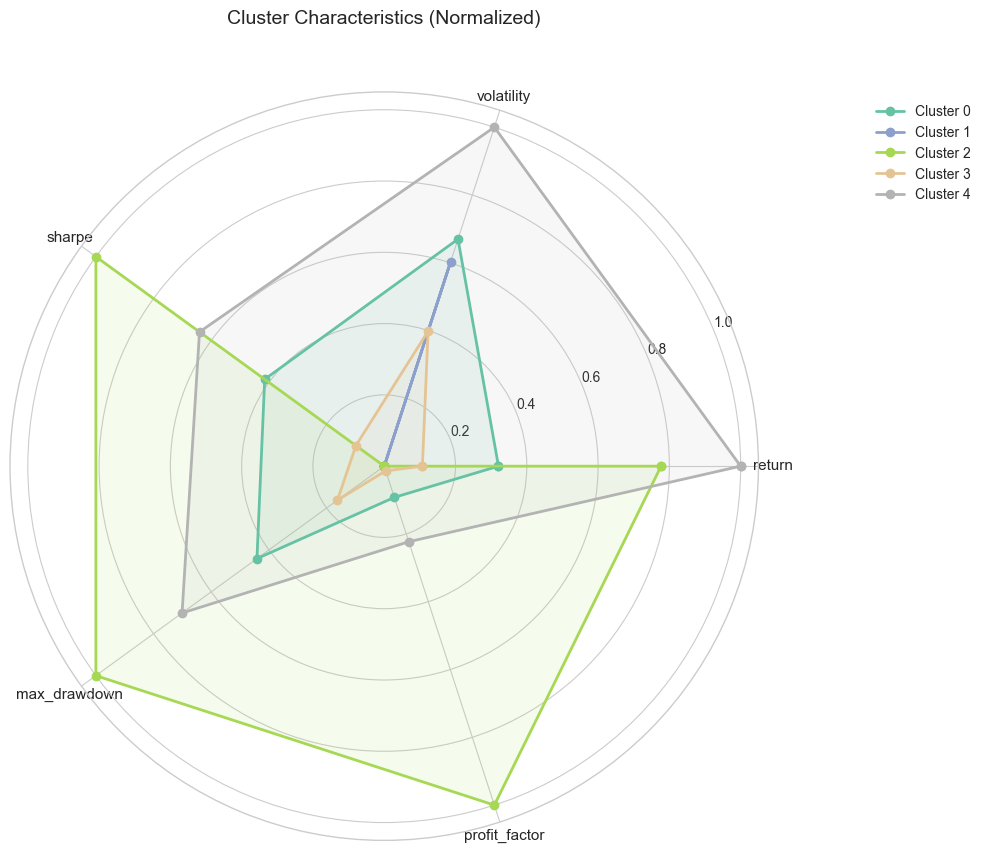

In [51]:
# Visualize cluster characteristics with radar chart
if algo_features_path.exists() and 'cluster_means' in dir() and len(cluster_means) > 0:
    from math import pi
    
    # Select features for radar chart (normalize to 0-1 scale)
    radar_features = ['return', 'volatility', 'sharpe', 'max_drawdown', 'profit_factor']
    radar_features = [f for f in radar_features if f in cluster_means.columns]
    
    if len(radar_features) >= 3:
        # Normalize features to 0-1 scale
        radar_data = cluster_means[radar_features].copy()
        for col in radar_data.columns:
            min_val, max_val = radar_data[col].min(), radar_data[col].max()
            if max_val > min_val:
                radar_data[col] = (radar_data[col] - min_val) / (max_val - min_val)
            else:
                radar_data[col] = 0.5
        
        # Number of variables
        num_vars = len(radar_features)
        
        # Compute angle for each feature
        angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
        angles += angles[:1]  # Complete the loop
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
        
        # Plot each cluster
        colors = plt.cm.Set2(np.linspace(0, 1, len(radar_data)))
        
        for idx, (cluster_id, row) in enumerate(radar_data.iterrows()):
            values = row.values.flatten().tolist()
            values += values[:1]  # Complete the loop
            
            ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=colors[idx])
            ax.fill(angles, values, alpha=0.1, color=colors[idx])
        
        # Set feature labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(radar_features, size=11)
        
        ax.set_title('Cluster Characteristics (Normalized)', size=14, y=1.08)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not enough features for radar chart (need 3+, have {len(radar_features)})")

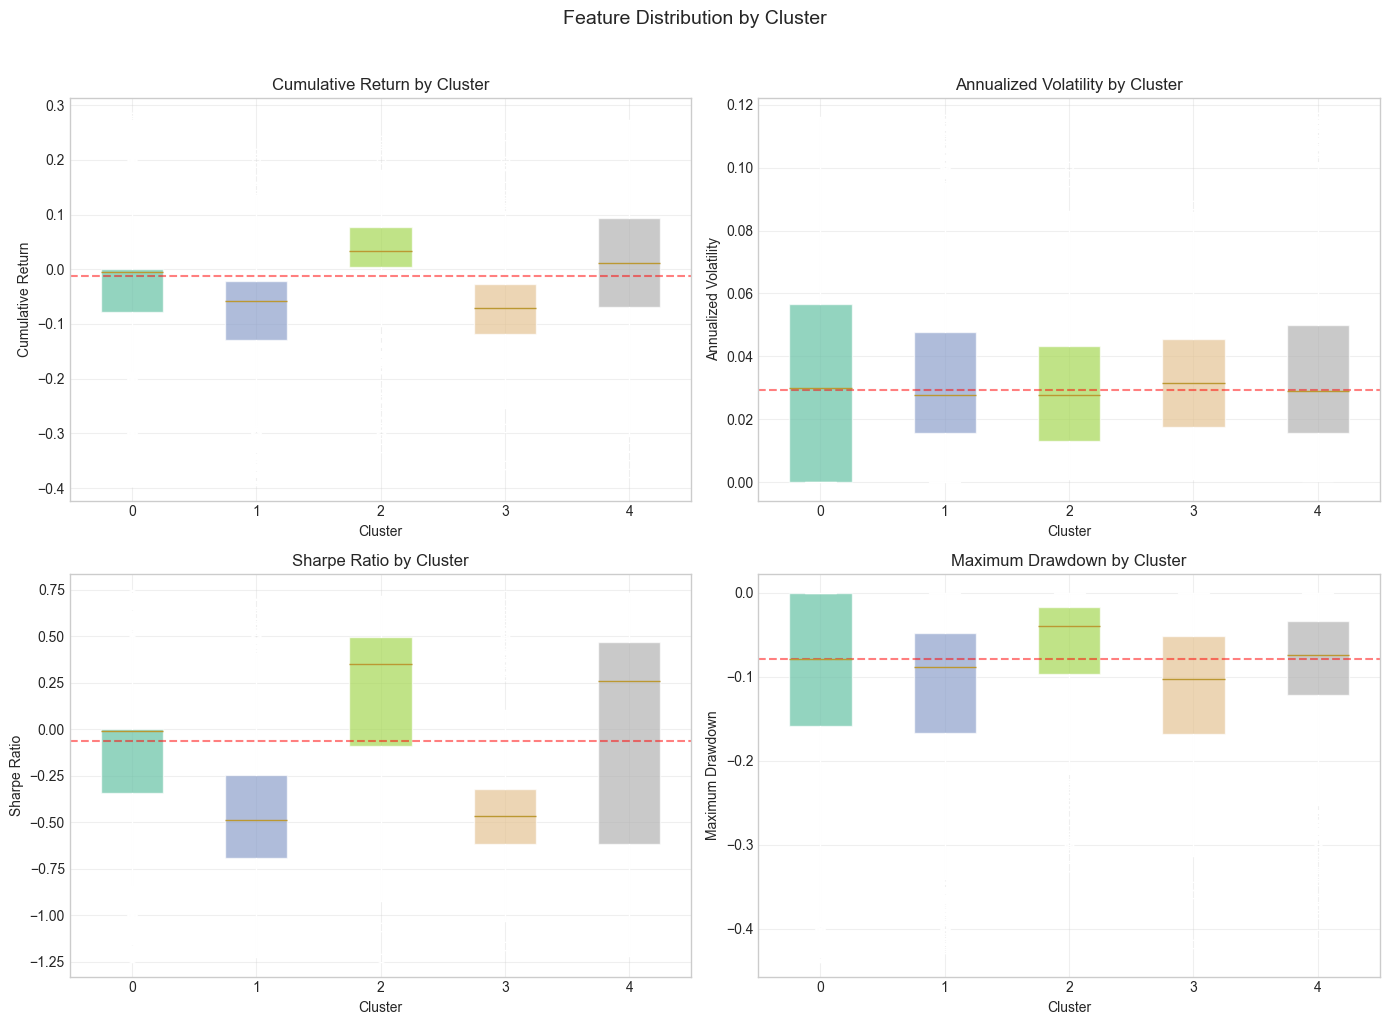

In [52]:
# Box plots of features by cluster
if algo_features_path.exists() and 'cluster_merged_active' in dir() and len(cluster_merged_active) > 0:
    plot_features = ['return', 'volatility', 'sharpe', 'max_drawdown']
    plot_features = [f for f in plot_features if f in cluster_merged_active.columns]
    
    n_features = len(plot_features)
    if n_features > 0:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        titles = {
            'return': 'Cumulative Return',
            'volatility': 'Annualized Volatility', 
            'sharpe': 'Sharpe Ratio',
            'max_drawdown': 'Maximum Drawdown'
        }
        
        for i, feat in enumerate(plot_features[:4]):
            ax = axes[i]
            
            # Filter outliers for better visualization (1st to 99th percentile)
            data = cluster_merged_active.copy()
            q01, q99 = data[feat].quantile([0.01, 0.99])
            data = data[(data[feat] >= q01) & (data[feat] <= q99)]
            
            # Create box plot
            clusters = sorted(data['dominant_cluster'].unique())
            box_data = [data[data['dominant_cluster'] == c][feat].values for c in clusters]
            
            bp = ax.boxplot(box_data, tick_labels=clusters, patch_artist=True)
            
            # Color the boxes
            colors = plt.cm.Set2(np.linspace(0, 1, len(clusters)))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            ax.set_xlabel('Cluster')
            ax.set_ylabel(titles.get(feat, feat))
            ax.set_title(f'{titles.get(feat, feat)} by Cluster')
            ax.grid(True, alpha=0.3)
            
            # Add median line
            ax.axhline(data[feat].median(), color='red', linestyle='--', alpha=0.5, label='Overall Median')
        
        # Hide empty subplots
        for i in range(n_features, 4):
            axes[i].set_visible(False)
        
        plt.suptitle('Feature Distribution by Cluster', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()

In [53]:
# Save cluster characteristics to file
if algo_features_path.exists() and 'cluster_means' in dir() and len(cluster_means) > 0:
    # Save cluster characteristics
    cluster_chars_output = cluster_means.copy()
    cluster_chars_output['n_algorithms'] = cluster_merged_active.groupby('dominant_cluster').size()
    cluster_chars_output['description'] = cluster_descriptions
    
    output_file = CLUSTER_PATH / 'cluster_characteristics.csv'
    cluster_chars_output.to_csv(output_file)
    print(f"Saved cluster characteristics to: {output_file}")
    display(cluster_chars_output)

Saved cluster characteristics to: ..\data\processed\temporal_clusters\cluster_characteristics.csv


,return,volatility,drawdown,sharpe,profit_factor,calmar_ratio,max_drawdown,n_algorithms,description
dominant_cluster,,,,,,,,,
0,-0.045031,0.034938,-0.083188,-0.164696,0.864804,-0.041588,-0.102184,10559,High Return | Negative Sharpe | Losing (PF<1)
1,-0.088249,0.034494,-0.111296,-0.475510,0.725636,-0.089148,-0.124826,1441,Low/Negative Return | Negative Sharpe | Losing...
2,0.016485,0.030475,-0.051832,0.274212,2.237066,0.423144,-0.073531,237,High Return | Low Drawdown (<10%) | High Profi...
3,-0.073804,0.033129,-0.101990,-0.401872,0.746878,-0.069529,-0.116501,262,Low/Negative Return | Negative Sharpe | Losing...
4,0.046575,0.037138,-0.065344,0.004786,1.062598,0.149557,-0.088862,1014,High Return | Low Drawdown (<10%)


## 8. Summary

In [54]:
print("="*70)
print("CLUSTER ANALYSIS SUMMARY")
print("="*70)

print(f"\nDATA OVERVIEW:")
print(f"  - Total algorithms: {cluster_history['algo_id'].nunique()}")
print(f"  - Total weeks analyzed: {cluster_history['week_end'].nunique()}")
print(f"  - Date range: {cluster_history['week_end'].min().date()} to {cluster_history['week_end'].max().date()}")
print(f"  - Number of clusters: {params.get('n_clusters', 'N/A')}")
print(f"  - Clustering method: {params.get('method', 'N/A')}")

print(f"\nSTABILITY METRICS:")
print(f"  - Mean cumulative stability: {stability_cumulative['stability'].mean():.3f}")
print(f"  - Mean weekly stability: {stability_weekly['stability'].mean():.3f}")
print(f"  - Mean monthly stability: {stability_monthly['stability'].mean():.3f}")

if method_comparisons:
    print(f"\nBEST METHODS (by silhouette):")
    for horizon, df in method_comparisons.items():
        best = df['avg_silhouette'].idxmax()
        print(f"  - {horizon.title()}: {best}")

print(f"\nKEY INSIGHTS:")
print(f"  - Cumulative clusters are most stable (long-term performance patterns persist)")
print(f"  - Weekly clusters show more volatility (short-term dynamics)")
print(f"  - {len(stability_cumulative[stability_cumulative['stability'] > 0.8])} algorithms have >80% cumulative stability")
print(f"  - {len(stability_cumulative[stability_cumulative['n_unique_clusters'] == 1])} algorithms never changed cluster")

CLUSTER ANALYSIS SUMMARY

DATA OVERVIEW:
  - Total algorithms: 13513
  - Total weeks analyzed: 240
  - Date range: 2020-06-05 to 2025-01-03
  - Number of clusters: 5
  - Clustering method: kmeans

STABILITY METRICS:
  - Mean cumulative stability: 0.297
  - Mean weekly stability: 0.349
  - Mean monthly stability: 0.376

BEST METHODS (by silhouette):
  - Cumulative: kmeans
  - Weekly: kmeans
  - Monthly: kmeans

KEY INSIGHTS:
  - Cumulative clusters are most stable (long-term performance patterns persist)
  - Weekly clusters show more volatility (short-term dynamics)
  - 3 algorithms have >80% cumulative stability
  - 3 algorithms never changed cluster
